In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from randomness import *
from simulation_exact import *
from utils import *
from data_analysis import *
from main import *
import numpy as np
import warnings
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
from matplotlib.colors import Normalize
from joblib import Parallel, delayed
warnings.filterwarnings("ignore")
seed = 42
np.random.seed(seed)
rng = np.random.default_rng(seed)

In [ ]:
def generate_data_d(n, mu1, mu2, rng, sigma = [1.0, 1.0], d=1):
    X1 = rng.normal(loc=mu1, scale=sigma[1], size=(n[1], d))
    X2 = rng.normal(loc=mu2, scale=sigma[0], size=(n[0], d))
    X = np.vstack([X1, X2])
    y = np.concatenate([
        -1 * np.ones(n[1]),
        np.ones(n[0])
    ])

    v = np.ones(n[0]+n[1])

    return X, y, v

In the block below, start by setting the parameters for the learning model  (lines 1-10 in block below)

experiments: (two blocks down )

1. to run the expirement for the same sample while changing mu_1 - mu_2, <br>
    remove the comments in lines 12 and 17 <br>
    comment line 16 <br>
    set T = 1 <br>

2. to run the expirement for the different samples and averaging over each T samples , <br>
    comments  lines 12 and 17 <br>
    remove comment line 16 <br>
    set T to be number of samples to be drawn per mu (line 12) <br>
 
In both cases you can choose parameters in lines 11-13, in the block below: <br>
    ds:= different dimensions to run the expierments on (line 11) <br>
    mus:= different mus to run the experiments on, where one distrbution has mean mu and the other has -mu (line 13)
    

In [10]:
# 1. choose parameters 
n_pos = 25 # number of data points in a sample with label 1
n_neg = 25 # number of data points in a sample with label -1
n = [n_pos, n_neg]
sigma_pos = 1.0 # data sd for generating process 
sigma_neg = 1.5 # data sd for generating process 
sigma = [sigma_pos , sigma_neg] 
# ---------------------------------
use_loss = 'hinge' #'log' or 'hinge' or 'squared_hinge' 
sigma_loss = 1.0 #TODO: double check if integration needed in more functions 
c = 1.0 # choose c without scaling 
show_plots = False # set to True to see plots of the binary search
is_throw = True # set to True to throw out points outside margin --> only when loss is lipschitz. 
#TODO: add is throw to outside_inside function 
k = None # if none will be set based on data max norm
k_coef = 1.0 # coefficient to multiply k with
fit_intercept = True # whether to fit intercept in SVM model
# ---------------------------------
ds = [2, 4, 6, 10, 12] # dimensions to run experiments on
#ds = [6]
T = 100 # number of trials
mus = np.linspace(1.0, 0.0, 21) # different mus to run the experiments on


In [15]:
# 3. run exact simulation
# returns df with cols "agent" | "true_v" | "critical_v" | "allocation" | "welfare" | "utility"
# utility = welfare - payment
# welfare = allocation * true_v
# critical_v = payment 

def compute_num_payers_for_d(d):#, k = None):
    # num_payers = np.zeros(len(mus))
    num_payers = {i: [] for i in range(len(mus))}
    for _ in range(T):
        #x, y, v = generate_data_d(n, mus[0], -mus[0], rng, sigma, d)
        for i, mu in enumerate(mus):
            x, y, v = generate_data_d(n, mu, -mu, rng, sigma, d)
            #x_updated = update_data(x, y, mu, -mu)
            df_exact, _ = run_exact(x, y, v, c, use_loss, sigma_loss=sigma_loss, plot=show_plots, 
                                    is_throw=is_throw, k=k, k_coef=k_coef, fit_intercept=fit_intercept)
            
            if df_exact is not None:
                num_rows = (df_exact['critical_v'] > 0).sum()
                num_payers[i].append(num_rows)

    return d, num_payers 


/home/sadi.bana/.local/lib/python3.10/site-packages/sklearn/svm/_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


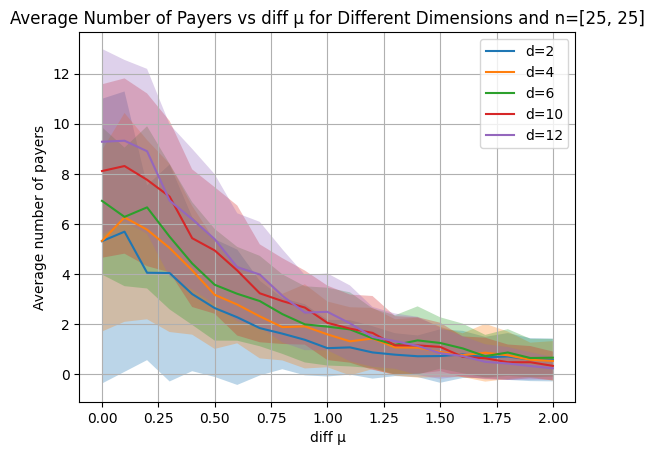

In [16]:
results = Parallel(n_jobs=-1, backend="loky")(
    delayed(compute_num_payers_for_d)(d) for d in ds
)

results = dict(results)  # {d: num_payers}
for d, num_payers in results.items():
    mean_num_payers = np.array([np.mean(num_payers[i]) for i in range(len(mus))])
    sd_num_payers = np.array([np.std(num_payers[i]) for i in range(len(mus))])
    plt.plot(2*mus, mean_num_payers, label=f"d={d}")
    plt.fill_between(2*mus, mean_num_payers - sd_num_payers, mean_num_payers + sd_num_payers, alpha=0.3)

plt.xlabel("diff μ")
plt.ylabel("Average number of payers")
plt.legend()
plt.grid(True)
plt.title(f"Average Number of Payers vs diff μ for Different Dimensions and n={n}")
plt.show()

TODO: <br>
<ul>
     <li> add sd hue + </li>
     <li>add a change in sigma_data and n_data </li>
     <li>create micro notebook </li>
     <li>check for beta data </li>
</ul>

